# Examples of using the microbial_hypergraphs package

## Getting raw data as dataframes

In [ ]:
import microbial_hypergraphs as mh
from microbial_hypergraphs.core.data import get_otu_samples, get_sample_info, get_taxonomy

sample_info = get_sample_info()
sample_info["Country"].unique()

## Running a hypercorrelation and getting results as a dataframe

In [1]:
# Standard way to import the package
import microbial_hypergraphs as mh

# List the names of objects that can be referred to in function calls
mh.print_names()

                                                    Populations                                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Name                        ┃ Description                                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ PresentInAllSamples         │ OTUs that show up in ALL samples.                                                 │
│ PresentInAllSamples_Spain   │ OTUs that show up in ALL samples. Only Spain samples considered for statistics.   │
│ PresentInAllSamples_France  │ OTUs that show up in ALL samples. Only France samples considered for statistics.  │
│ PresentInAllSamples_Sweden  │ OTUs that show up in ALL samples. Only Sweden samples considered for statistics.  │
│ PresentInAllSamples_Germany │ OTUs that show up in ALL samples. Only Germany samples considered for statistics. │
│ PresentInAllSamples_Sweden  │ OTUs that show up in ALL samples. Only Switzerland samples considered for         │
│                             │ statistics.                                                                       │
└─────────────────────────────┴───────────────────────────────────────────────────────────────────────────────────┘

                 Correlations                  
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Name    ┃ Description                       ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Pearson │ The standard Pearson correlation. │
└─────────┴───────────────────────────────────┘

                               Hypercorrelations                               
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Name       ┃ Description                                                    ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Minimal    │ The smallest pairwise correlation in the group.                │
│ Arithmetic │ The arithmetic mean of the pairwise correlations in the group. │
└────────────┴────────────────────────────────────────────────────────────────┘

In [ ]:
# Plotting hypergraph for Spain
hn = mh.get_hypernetwork(
    population_name="PresentInAllSamples_Spain",
    correlation_name="Pearson",
    hypercorrelation_name="Minimal",
    max_group_size=4,
    threshold=0.6
)
from matplotlib import colormaps as cm

hn.draw(reduced=True, minimum_group_size=3, node_color_map=cm['Greens'])

In [ ]:
# Plotting hypergraph for Germany
hn = mh.get_hypernetwork(
    population_name="PresentInAllSamples_Germany",
    correlation_name="Pearson",
    hypercorrelation_name="Minimal",
    max_group_size=4,
    threshold=0.6
)
from matplotlib import colormaps as cm

hn.draw(reduced=True, minimum_group_size=3, node_color_map=cm['Greens'])

## Using matplotlib along with Hypernetwork.draw to compare countries

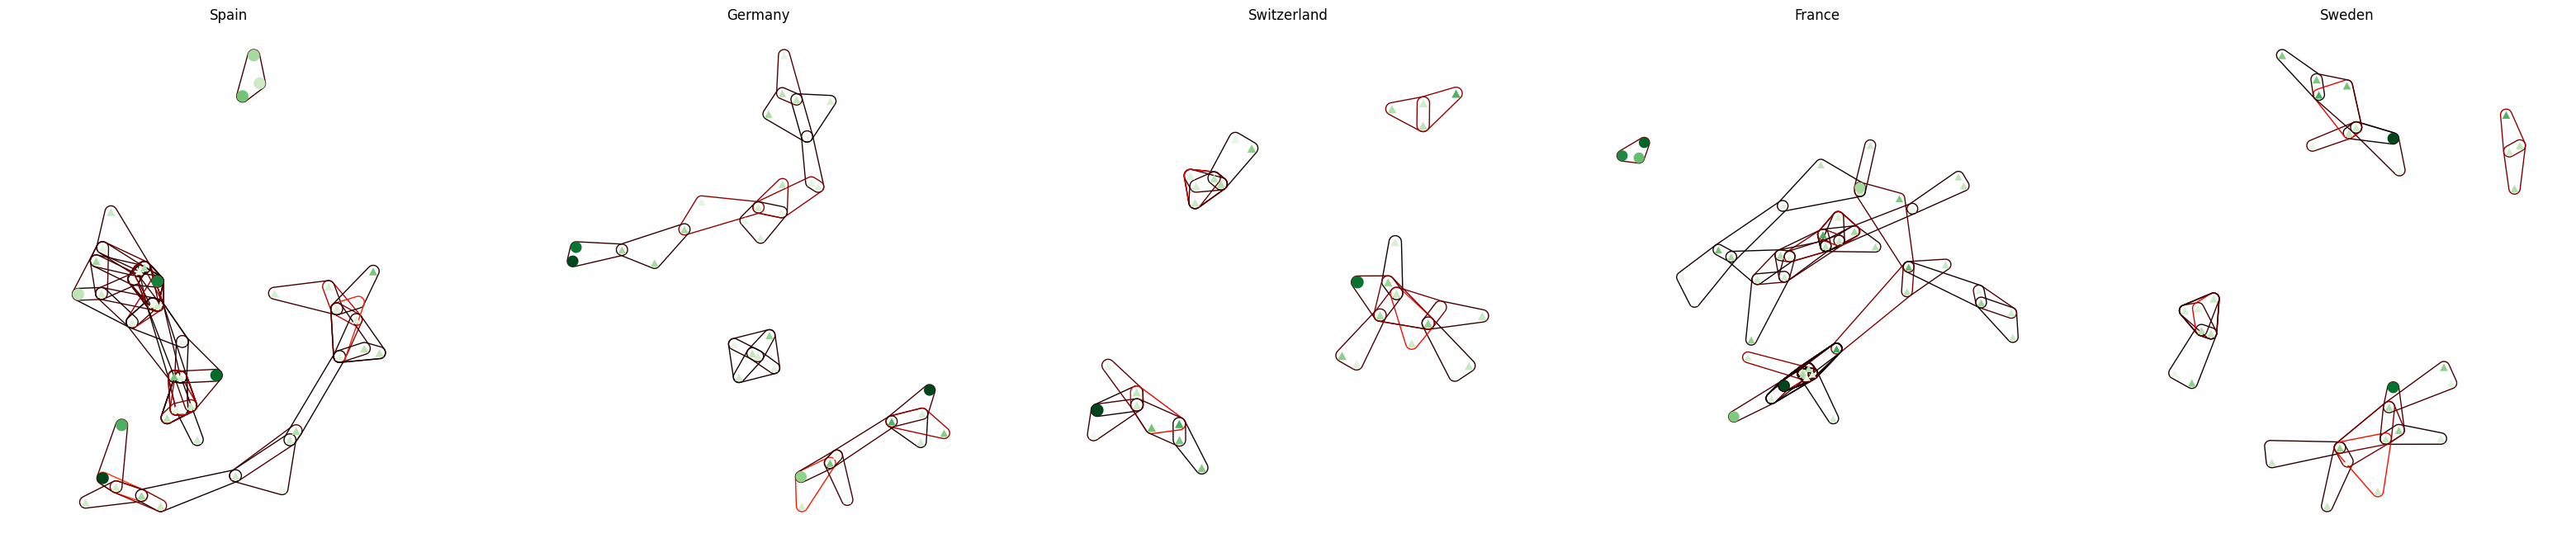

In [2]:
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

import microbial_hypergraphs as mh

fig, ax = plt.subplots(nrows=1,ncols=5, figsize=(40, 8))

for i, country in enumerate(["Spain", "Germany", "Switzerland", "France", "Sweden"]):
    h = mh.get_hypernetwork(
        population_name="PresentInAllSamples_" + country,
        correlation_name="Pearson",
        hypercorrelation_name="Minimal",
        max_group_size=4,
        threshold=0.6
    )
    h.draw(
        reduced=True,
        minimum_group_size=3,
        edge_color_map=cm['hot'],
        ax=ax[i]
    )
    ax[i].set_title(country)